# Penalty and Sanction Patterns Analysis

**Paper 2: Cross-Code Comparative Analysis - Part 3**

This notebook analyzes punishment and sanction patterns in Kazakhstan's Criminal and Administrative Codes:
- Criminal Code (УК) - criminal penalties
- Administrative Code (КоАП) - administrative penalties

**Analysis dimensions:**
1. Penalty type extraction (fines, imprisonment, etc.)
2. Penalty severity distribution
3. Fine amount patterns (in MRP - Месячный Расчетный Показатель / Monthly Calculation Index)
4. Imprisonment term patterns
5. Comparison between Criminal and Administrative penalties
6. Penalty patterns by section/chapter

## 1. Setup and Imports

In [2]:
import json
import pandas as pd
import numpy as np
from pathlib import Path
from collections import Counter
import re
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Configure matplotlib
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['figure.dpi'] = 100

print("Setup complete!")

Setup complete!


## 2. Data Loading

In [3]:
DATA_PATH = Path("../data/raw/by_history")

def load_latest_version(history_folder):
    """Load the latest version of a legal code from historical data."""
    folder_path = DATA_PATH / history_folder
    index_path = folder_path / "versions_index.json"
    
    with open(index_path, "r", encoding="utf-8") as f:
        index = json.load(f)
    
    latest_version = index["versions"][-1]
    version_file = folder_path / latest_version["filename"]
    
    with open(version_file, "r", encoding="utf-8") as f:
        data = json.load(f)
    
    return data["articles"], latest_version

# Load Criminal Code
criminal_data, criminal_version = load_latest_version("K1400000226_rus_ugolov")
print(f"Criminal Code: {len(criminal_data)} articles loaded (version {criminal_version['version_number']}, {criminal_version['version_date']})")

# Load Administrative Code
admin_data, admin_version = load_latest_version("K1400000235_rus_adm")
print(f"Administrative Code: {len(admin_data)} articles loaded (version {admin_version['version_number']}, {admin_version['version_date']})")

Criminal Code: 502 articles loaded (version 109, 16.09.2025)
Administrative Code: 1066 articles loaded (version 205, 17.12.2025)


## 3. Penalty Pattern Extraction

### 3.1 Russian Number Parsing

In [4]:
# Russian number word dictionaries for parsing compound numbers
# MRP = Месячный Расчетный Показатель (Monthly Calculation Index)

UNITS = {
    'один': 1, 'одного': 1, 'одному': 1, 'одним': 1, 'одной': 1, 'одна': 1,
    'два': 2, 'двух': 2, 'двум': 2, 'двумя': 2, 'две': 2,
    'три': 3, 'трех': 3, 'трём': 3, 'тремя': 3,
    'четыре': 4, 'четырех': 4, 'четырём': 4, 'четырьмя': 4,
    'пять': 5, 'пяти': 5, 'пятью': 5,
    'шесть': 6, 'шести': 6, 'шестью': 6,
    'семь': 7, 'семи': 7, 'семью': 7,
    'восемь': 8, 'восьми': 8, 'восемью': 8,
    'девять': 9, 'девяти': 9, 'девятью': 9,
}

TEENS = {
    'десять': 10, 'десяти': 10, 'десятью': 10,
    'одиннадцать': 11, 'одиннадцати': 11,
    'двенадцать': 12, 'двенадцати': 12,
    'тринадцать': 13, 'тринадцати': 13,
    'четырнадцать': 14, 'четырнадцати': 14,
    'пятнадцать': 15, 'пятнадцати': 15,
    'шестнадцать': 16, 'шестнадцати': 16,
    'семнадцать': 17, 'семнадцати': 17,
    'восемнадцать': 18, 'восемнадцати': 18,
    'девятнадцать': 19, 'девятнадцати': 19,
}

TENS = {
    'двадцать': 20, 'двадцати': 20,
    'тридцать': 30, 'тридцати': 30,
    'сорок': 40, 'сорока': 40,
    'пятьдесят': 50, 'пятидесяти': 50,
    'шестьдесят': 60, 'шестидесяти': 60,
    'семьдесят': 70, 'семидесяти': 70,
    'восемьдесят': 80, 'восьмидесяти': 80,
    'девяносто': 90, 'девяноста': 90,
}

HUNDREDS = {
    'сто': 100, 'ста': 100,
    'двести': 200, 'двухсот': 200,
    'триста': 300, 'трехсот': 300,
    'четыреста': 400, 'четырехсот': 400,
    'пятьсот': 500, 'пятисот': 500,
    'шестьсот': 600, 'шестисот': 600,
    'семьсот': 700, 'семисот': 700,
    'восемьсот': 800, 'восьмисот': 800,
    'девятьсот': 900, 'девятисот': 900,
}

THOUSANDS = {'тысяча': 1000, 'тысячи': 1000, 'тысяч': 1000}

# Combined lookup for simple cases
RUSSIAN_NUMBERS = {**UNITS, **TEENS, **TENS, **HUNDREDS, **THOUSANDS}

print(f"Russian number dictionaries loaded: {len(RUSSIAN_NUMBERS)} words")

Russian number dictionaries loaded: 92 words


In [5]:
def parse_compound_russian_number(text):
    """Parse compound Russian numbers like 'ста двадцати' → 120, 'одной тысячи' → 1000"""
    if text is None:
        return None
    
    text = text.strip().lower()
    
    # Remove leading "до" or "от" if present
    text = re.sub(r'^(до|от)\s+', '', text)
    
    # Try direct digit match first
    if text.isdigit():
        return int(text)
    
    # Try simple lookup
    if text in RUSSIAN_NUMBERS:
        return RUSSIAN_NUMBERS[text]
    
    # Parse compound number word by word
    words = text.split()
    total = 0
    current = 0
    
    for word in words:
        if word in THOUSANDS:
            current = (current if current else 1) * 1000
            total += current
            current = 0
        elif word in HUNDREDS:
            current += HUNDREDS[word]
        elif word in TENS:
            current += TENS[word]
        elif word in TEENS:
            current += TEENS[word]
        elif word in UNITS:
            current += UNITS[word]
        elif word.isdigit():
            current += int(word)
    
    result = total + current
    return result if result > 0 else None

# Test compound number parsing
test_cases = [
    ("семисот пятидесяти", 750),
    ("тысячи пятисот", 1500),
    ("одной тысячи", 1000),
    ("ста двадцати", 120),
    ("до ста двадцати", 120),
    ("100", 100),
]
print("Testing compound number parsing:")
for text, expected in test_cases:
    result = parse_compound_russian_number(text)
    status = "✓" if result == expected else f"✗ (got {result})"
    print(f"  '{text}' → {expected} {status}")

Testing compound number parsing:
  'семисот пятидесяти' → 750 ✓
  'тысячи пятисот' → 1500 ✓
  'одной тысячи' → 1000 ✓
  'ста двадцати' → 120 ✓
  'до ста двадцати' → 120 ✓
  '100' → 100 ✓


### 3.2 Penalty Pattern Definitions

In [6]:
# Unified penalty patterns (used for both Criminal and Administrative codes)
# Patterns handle three formats:
# 1. "от X до Y" (range) - captures min and max
# 2. "до X" (only max) - captures max only
# 3. "X" (exact) - captures as both min and max
#
# Note: [^,]+ is used instead of .+ to stop at commas, preventing capture of
# multiple fine values for different subject types in Administrative Code

PENALTY_PATTERNS = {
    "fine_mrp": {
        # Primary pattern: "штраф в размере X месячных"
        "pattern": r'штраф\w*\s+(?:в\s+размере\s+)?(?:от\s+([^,]+?)\s+до\s+([^,]+?)|до\s+([^,]+?)|([^,]+?))\s+месячн',
        "groups": ["min", "max", "max_only", "exact"],
        "value_type": "mrp"
    },
    "fine_mrp_subject": {
        # Admin Code multi-subject pattern: "штраф на физических лиц в размере X,"
        # Captures first fine amount in multi-subject penalty descriptions
        "pattern": r'штраф\w*\s+на\s+(?:физическ|должностн|юридическ)\w+\s+(?:лиц\w*\s+)?в\s+размере\s+(\d+|[а-яё]+(?:\s+[а-яё]+)?)\s*(?:,|месячн)',
        "groups": ["exact"],
        "value_type": "mrp"
    },
    "imprisonment_years": {
        "pattern": r'лишени\w*\s+свободы\s+(?:на\s+(?:тот\s+же\s+)?срок|на\s+срок\s+(?:от\s+(.+?)\s+до\s+(.+?)|до\s+(.+?))\s*(?:года?|лет))',
        "groups": ["min", "max", "max_only"],
        "value_type": "years"
    },
    "restriction_freedom": {
        "pattern": r'ограничени\w*\s+свободы\s+(?:на\s+(?:тот\s+же\s+)?срок|на\s+срок\s+(?:от\s+(.+?)\s+до\s+(.+?)|до\s+(.+?))\s*(?:года?|лет))',
        "groups": ["min", "max", "max_only"],
        "value_type": "years"
    },
    "correctional_work": {
        "pattern": r'исправительн\w+\s+работ',
        "groups": [],
        "value_type": None
    },
    "community_service_hours": {
        "pattern": r'общественн\w+\s+работ\w*\s+(?:на\s+срок\s+)?(?:от\s+(.+?)\s+до\s+(.+?)|до\s+(.+?))\s*час',
        "groups": ["min", "max", "max_only"],
        "value_type": "hours"
    },
    "arrest_days": {
        "pattern": r'(?:административн\w+\s+)?арест\w*\s+(?:на\s+срок\s+)?(?:до\s+)?(.+?)\s*(?:суток|сутки|дней)',
        "groups": ["max"],
        "value_type": "days"
    },
    "warning": {
        "pattern": r'предупреждени[еяю]м?(?:\s|,|;|$)',
        "groups": [],
        "value_type": None
    },
    "confiscation": {
        "pattern": r'конфискаци[еяюи]',
        "groups": [],
        "value_type": None
    },
    "life_imprisonment": {
        "pattern": r'пожизненн\w+\s+(?:лишени\w+\s+свободы|заключени)',
        "groups": [],
        "value_type": None
    },
    "deprivation_right": {
        "pattern": r'лишени\w*\s+права\s+заним',
        "groups": [],
        "value_type": None
    },
    "suspension": {
        "pattern": r'приостановлени\w*\s+(?:деятельности|лицензии|действия|разрешения)',
        "groups": [],
        "value_type": None
    },
    "deportation": {
        "pattern": r'(?:выдворени\w*|депортаци\w+)',
        "groups": [],
        "value_type": None
    },
    "license_revocation": {
        "pattern": r'лишени\w*\s+(?:специального\s+права|лицензии|разрешения)',
        "groups": [],
        "value_type": None
    },
    "death_penalty_mention": {
        "pattern": r'смертн\w+\s+казн[ьи]',
        "groups": [],
        "value_type": None
    },
}

print(f"Defined {len(PENALTY_PATTERNS)} penalty patterns")

Defined 15 penalty patterns


### 3.3 Extraction Functions

In [7]:
def extract_number_from_text(text):
    """Extract number from text - handles both digits and Russian words."""
    if not text:
        return None
    
    text = text.strip().lower()
    
    # Try digit pattern first
    digit_match = re.search(r'(\d+)', text)
    if digit_match:
        return int(digit_match.group(1))
    
    # Try compound Russian number
    return parse_compound_russian_number(text)


def parse_penalty_section(penalty_text):
    """Parse a penalty section using unified PENALTY_PATTERNS."""
    penalties = []
    
    # Split by "либо" to get alternatives
    alternatives = re.split(r'\s+либо\s+', penalty_text, flags=re.IGNORECASE)
    
    for alt in alternatives:
        alt_lower = alt.strip().lower()
        
        # Try each pattern from PENALTY_PATTERNS
        for penalty_type, config in PENALTY_PATTERNS.items():
            match = re.search(config["pattern"], alt_lower, re.IGNORECASE)
            if match:
                penalty = {
                    "type": penalty_type,
                    "value_type": config["value_type"],
                    "raw": alt_lower[:80]
                }
                
                # Extract values based on group configuration
                groups = config["groups"]
                if groups and match.lastindex:
                    min_val = None
                    max_val = None
                    
                    for i, group_name in enumerate(groups):
                        group_idx = i + 1
                        if group_idx <= match.lastindex and match.group(group_idx):
                            value = extract_number_from_text(match.group(group_idx))
                            
                            if group_name == "min":
                                min_val = value
                            elif group_name == "max":
                                max_val = value
                            elif group_name == "max_only":
                                max_val = value
                            elif group_name == "exact":
                                min_val = value
                                max_val = value
                    
                    if min_val is not None:
                        penalty["min"] = min_val
                    if max_val is not None:
                        penalty["max"] = max_val
                
                penalties.append(penalty)
                break  # Only match first pattern per alternative
    
    return penalties

print("Helper functions defined: extract_number_from_text, parse_penalty_section")

Helper functions defined: extract_number_from_text, parse_penalty_section


In [8]:
def extract_penalties_by_part(articles, code_type):
    """Extract penalties grouped by article parts with alternatives."""
    results = []
    
    # Pattern for penalty trigger (наказывается/влечет/влекут)
    penalty_trigger = r'(?:наказывается|наказываются|влечет|влекут)\s+(.+?)(?:\.|$)'
    
    for article in articles:
        text = article.get("article_text", "")
        article_id = article.get("article_id", "")
        article_title = article.get("article_title", "")
        section = article.get("section", "")
        chapter = article.get("chapter", "")
        
        # Split into parts (часть 1, 2, 3...)
        part_pattern = r'(?:^|\n)\s*(\d+)[\.\)]\s*(.+?)(?=\n\s*\d+[\.\)]|\Z)'
        parts = re.findall(part_pattern, text, re.DOTALL)
        
        if not parts:
            parts = [("1", text)]
        
        for part_num, part_text in parts:
            penalty_matches = re.findall(penalty_trigger, part_text, re.IGNORECASE | re.DOTALL)
            
            for penalty_text in penalty_matches:
                penalties = parse_penalty_section(penalty_text)
                
                if penalties:
                    results.append({
                        "code_type": code_type,
                        "article_id": article_id,
                        "article_title": article_title,
                        "section": section,
                        "chapter": chapter,
                        "part": int(part_num),
                        "num_alternatives": len(penalties),
                        "penalties": penalties,
                        "penalty_types": [p.get("type") for p in penalties],
                    })
    
    return results

print("Main extraction function defined: extract_penalties_by_part")

Main extraction function defined: extract_penalties_by_part


### 3.4 Run Extraction

In [9]:
# Extract penalties from both codes
criminal_penalties_v2 = extract_penalties_by_part(criminal_data, "Criminal")
admin_penalties_v2 = extract_penalties_by_part(admin_data, "Administrative")

print(f"Criminal Code penalty groups: {len(criminal_penalties_v2):,}")
print(f"Administrative Code penalty groups: {len(admin_penalties_v2):,}")

# Show examples with multiple alternatives
example = [p for p in criminal_penalties_v2 if p["num_alternatives"] > 2][:3]
print(f"\nExamples with multiple alternatives:")
for ex in example:
    print(f"\n  {ex['article_title']} (part {ex['part']})")
    print(f"  Alternatives: {ex['num_alternatives']}")
    for p in ex['penalties']:
        min_v = p.get('min', '-')
        max_v = p.get('max', '-')
        unit = p.get('value_type', 'flag')
        print(f"    - {p.get('type')}: {min_v}-{max_v} {unit}")

Criminal Code penalty groups: 1,046
Administrative Code penalty groups: 1,578

Examples with multiple alternatives:

  Статья 107. Умышленное причинение средней тяжести вреда здоровью (part 1)
  Alternatives: 4
    - fine_mrp: --1000 mrp
    - correctional_work: --- None
    - community_service_hours: --600 hours
    - imprisonment_years: --- years

  Статья 108-1. Умышленное причинение легкого вреда здоровью (part 1)
  Alternatives: 4
    - fine_mrp: --200 mrp
    - correctional_work: --- None
    - community_service_hours: --200 hours
    - arrest_days: --50 days

  Статья 108-1. Умышленное причинение легкого вреда здоровью (part 8)
  Alternatives: 5
    - fine_mrp: --1000 mrp
    - correctional_work: --- None
    - community_service_hours: --600 hours
    - restriction_freedom: --- years
    - imprisonment_years: --- years


In [10]:
# Flatten the nested structure for DataFrame compatibility
def flatten_penalties(penalty_groups):
    """Convert grouped penalties to flat structure for analysis."""
    rows = []
    for group in penalty_groups:
        for penalty in group["penalties"]:
            rows.append({
                "code_type": group["code_type"],
                "article_id": group["article_id"],
                "article_title": group["article_title"],
                "section": group["section"],
                "chapter": group["chapter"],
                "part": group["part"],
                "num_alternatives": group["num_alternatives"],
                "penalty_type": penalty.get("type", "unknown"),
                "min_value": penalty.get("min"),
                "max_value": penalty.get("max"),
                "has_value": penalty.get("min") is not None or penalty.get("max") is not None
            })
    return rows

# Flatten and combine
all_penalties_flat = flatten_penalties(criminal_penalties_v2) + flatten_penalties(admin_penalties_v2)
penalties_df = pd.DataFrame(all_penalties_flat)

# Backward compatibility aliases for later cells
criminal_penalties = [p for p in all_penalties_flat if p["code_type"] == "Criminal"]
admin_penalties = [p for p in all_penalties_flat if p["code_type"] == "Administrative"]

print(f"Total penalty records: {len(penalties_df):,}")
print(f"\nPenalties by code type:")
print(penalties_df["code_type"].value_counts())

print(f"\nPenalty types found:")
print(penalties_df["penalty_type"].value_counts())

# Also create a grouped view for alternative analysis
penalties_grouped_df = pd.DataFrame(criminal_penalties_v2 + admin_penalties_v2)
print(f"\nPenalty groups (article-parts): {len(penalties_grouped_df):,}")
print(f"Groups with multiple alternatives: {(penalties_grouped_df['num_alternatives'] > 1).sum():,}")

penalties_df.head(5)

Total penalty records: 4,524

Penalties by code type:
code_type
Criminal          2859
Administrative    1665
Name: count, dtype: int64

Penalty types found:
penalty_type
fine_mrp                   1296
imprisonment_years          894
fine_mrp_subject            553
correctional_work           479
restriction_freedom         419
community_service_hours     402
arrest_days                 219
warning                     120
confiscation                 42
suspension                   40
life_imprisonment            28
license_revocation           20
deportation                  12
Name: count, dtype: int64

Penalty groups (article-parts): 2,624
Groups with multiple alternatives: 693


,code_type,article_id,article_title,section,chapter,part,num_alternatives,penalty_type,min_value,max_value,has_value
0,Criminal,z432,Статья 99. Убийство,РАЗДЕЛ 7. ПРИНУДИТЕЛЬНЫЕ МЕРЫ МЕДИЦИНСКОГО ХАР...,None,1,1,imprisonment_years,NaN,NaN,False
1,Criminal,z432,Статья 99. Убийство,РАЗДЕЛ 7. ПРИНУДИТЕЛЬНЫЕ МЕРЫ МЕДИЦИНСКОГО ХАР...,None,15,2,imprisonment_years,NaN,NaN,False
2,Criminal,z432,Статья 99. Убийство,РАЗДЕЛ 7. ПРИНУДИТЕЛЬНЫЕ МЕРЫ МЕДИЦИНСКОГО ХАР...,None,15,2,confiscation,NaN,NaN,False
3,Criminal,z432,Статья 99. Убийство,РАЗДЕЛ 7. ПРИНУДИТЕЛЬНЫЕ МЕРЫ МЕДИЦИНСКОГО ХАР...,None,3,1,life_imprisonment,NaN,NaN,False
4,Criminal,z434,Статья 100. Убийство матерью новорожденного ре...,РАЗДЕЛ 7. ПРИНУДИТЕЛЬНЫЕ МЕРЫ МЕДИЦИНСКОГО ХАР...,None,1,2,restriction_freedom,NaN,NaN,False


In [11]:
penalties_df[penalties_df['has_value']].head(3)

,code_type,article_id,article_title,section,chapter,part,num_alternatives,penalty_type,min_value,max_value,has_value
25,Criminal,z452,Статья 107. Умышленное причинение средней тяже...,РАЗДЕЛ 7. ПРИНУДИТЕЛЬНЫЕ МЕРЫ МЕДИЦИНСКОГО ХАР...,None,1,4,fine_mrp,NaN,1000.0,True
27,Criminal,z452,Статья 107. Умышленное причинение средней тяже...,РАЗДЕЛ 7. ПРИНУДИТЕЛЬНЫЕ МЕРЫ МЕДИЦИНСКОГО ХАР...,None,1,4,community_service_hours,NaN,600.0,True
30,Criminal,z2902,Статья 108-1. Умышленное причинение легкого вр...,РАЗДЕЛ 7. ПРИНУДИТЕЛЬНЫЕ МЕРЫ МЕДИЦИНСКОГО ХАР...,None,1,4,fine_mrp,NaN,200.0,True


## 4. Penalty Type Distribution

In [12]:
# Penalty type distribution by code
penalty_counts = penalties_df.groupby(["code_type", "penalty_type"]).size().unstack(fill_value=0)
print("Penalty Type Distribution:")
penalty_counts

Penalty Type Distribution:


penalty_type,arrest_days,community_service_hours,confiscation,correctional_work,deportation,fine_mrp,fine_mrp_subject,imprisonment_years,license_revocation,life_imprisonment,restriction_freedom,suspension,warning
code_type,,,,,,,,,,,,,
Administrative,81,2,28,0,12,809,553,0,20,0,0,40,120
Criminal,138,400,14,479,0,487,0,894,0,28,419,0,0


Shared penalty types across both codes: ['arrest_days', 'community_service_hours', 'confiscation', 'fine_mrp']


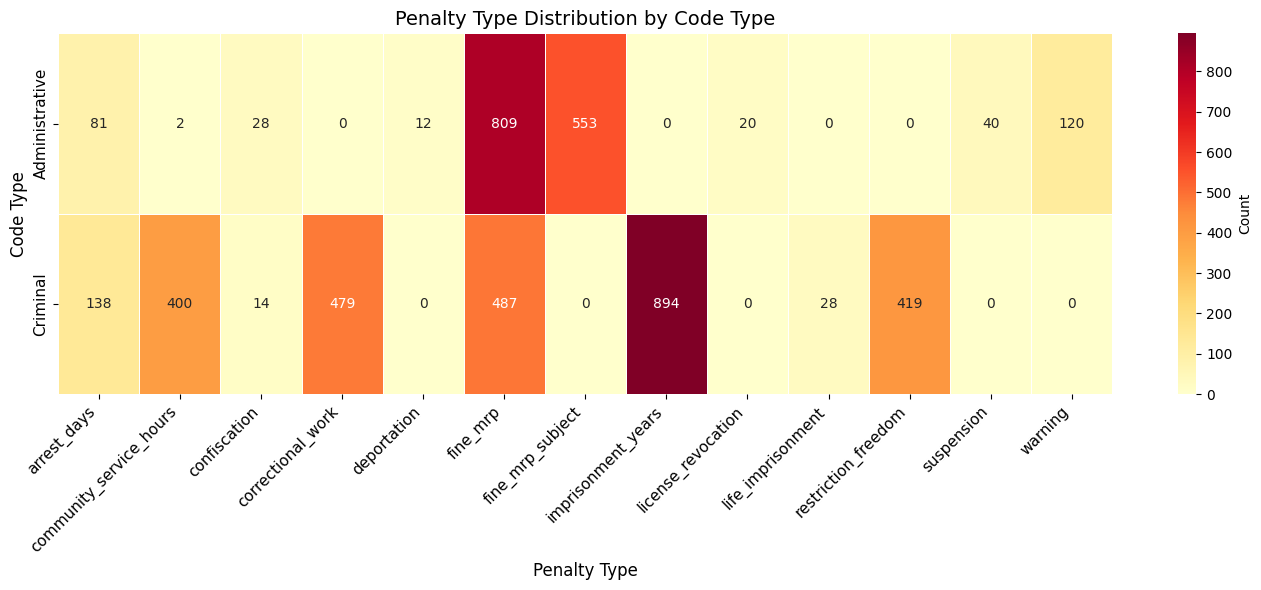

In [13]:
# Heatmap: Penalty type distribution across codes
plt.figure(figsize=(14, 6))
sns.heatmap(penalty_counts, annot=True, fmt='d', cmap='YlOrRd', 
            linewidths=0.5, cbar_kws={'label': 'Count'})
plt.title('Penalty Type Distribution by Code Type', fontsize=14)
plt.xlabel('Penalty Type', fontsize=12)
plt.ylabel('Code Type', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=11)

# Highlight shared penalties
shared = penalty_counts.columns[(penalty_counts > 0).all()]
print(f"Shared penalty types across both codes: {list(shared)}")

plt.tight_layout()
plt.savefig("../output/03/penalty_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()

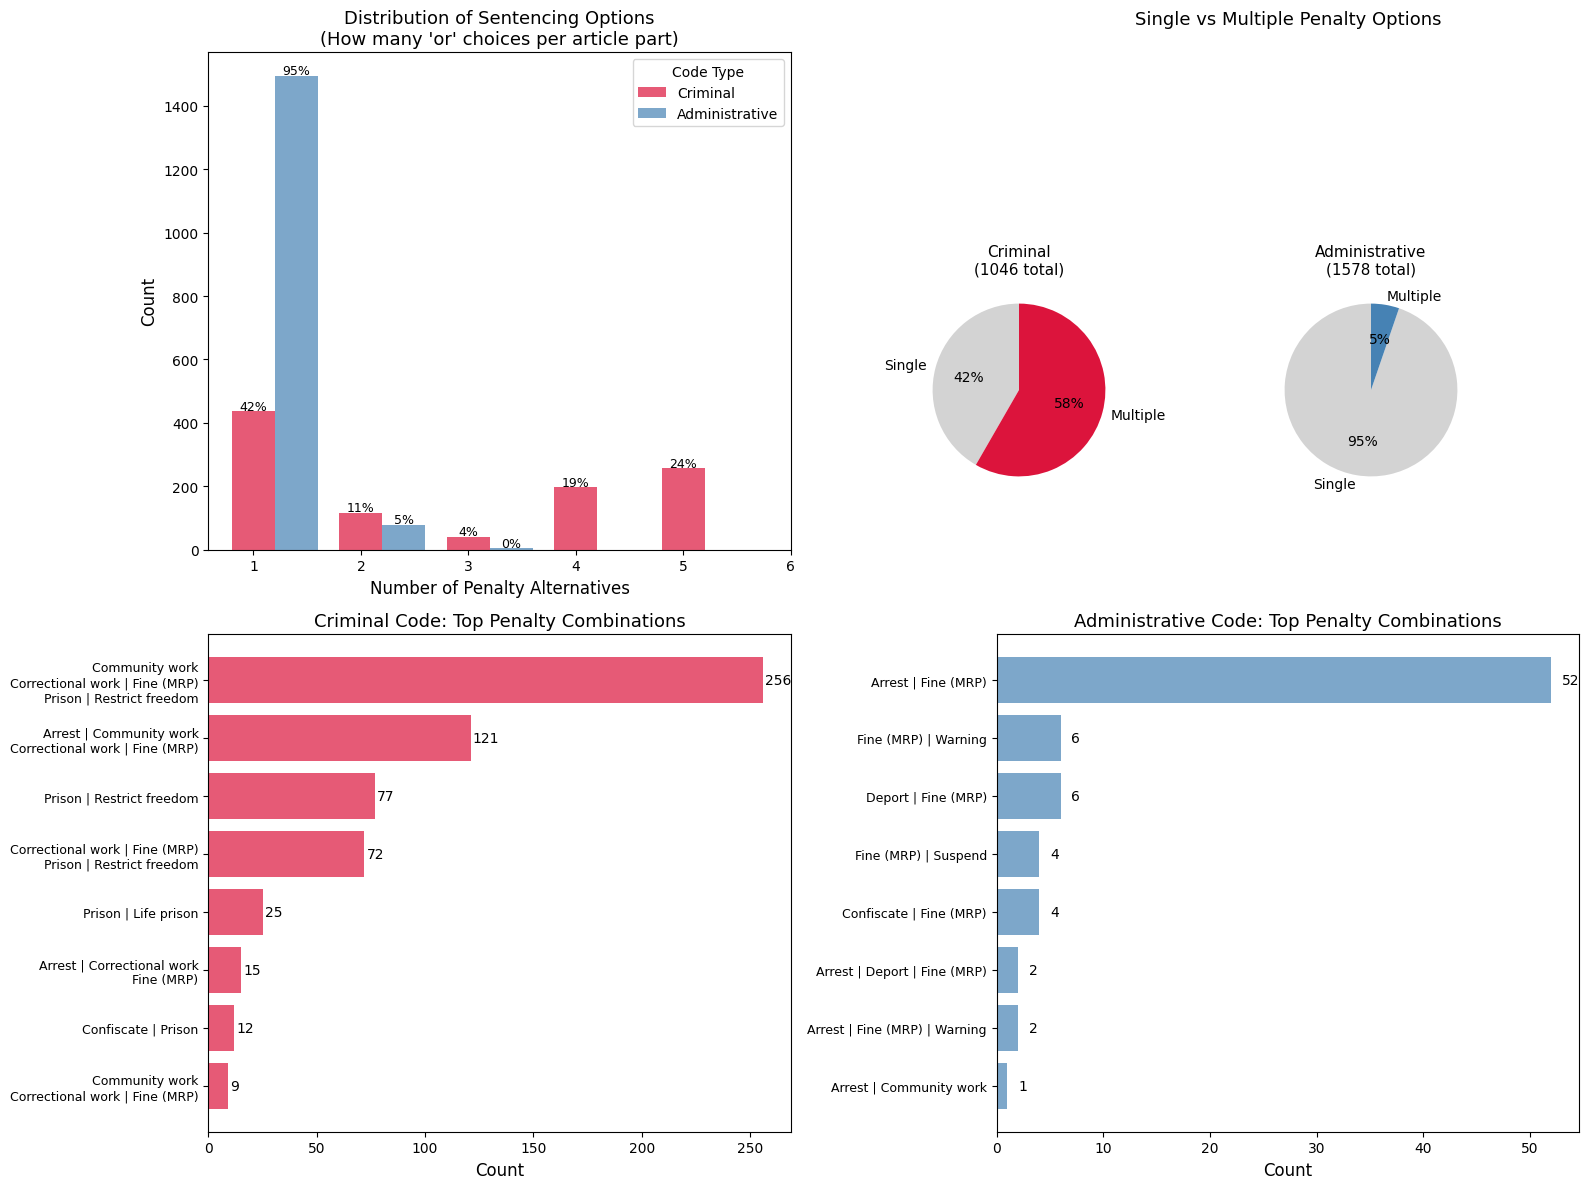

PENALTY ALTERNATIVES SUMMARY

Criminal Code:
  Total article-parts with penalties: 1,046
  Single penalty (no choice):         436 (41.7%)
  Multiple alternatives (choice):     610 (58.3%)
  Average alternatives per part:      2.73
  Maximum alternatives in one part:   5

Administrative Code:
  Total article-parts with penalties: 1,578
  Single penalty (no choice):         1,495 (94.7%)
  Multiple alternatives (choice):     83 (5.3%)
  Average alternatives per part:      1.06
  Maximum alternatives in one part:   3

ABBREVIATION KEY:
  Fine (MRP)           = fine_mrp
  Prison               = imprisonment_years
  Restrict freedom     = restriction_freedom
  Correctional work    = correctional_work
  Community work       = community_service_hours
  Arrest               = arrest_days
  Warning              = warning
  Confiscate           = confiscation
  Life prison          = life_imprisonment
  Deprivation right    = deprivation_right
  Suspend              = suspension
  Deport       

In [14]:
# Analyze penalty alternatives (either/or sentencing options)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Penalty type abbreviations for readability
PENALTY_ABBREV = {
    'fine_mrp': 'Fine (MRP)',
    'fine_mrp_subject': 'Fine (MRP)',  # Same display as fine_mrp
    'imprisonment_years': 'Prison',
    'restriction_freedom': 'Restrict freedom',
    'correctional_work': 'Correctional work',
    'community_service_hours': 'Community work',
    'arrest_days': 'Arrest',
    'warning': 'Warning',
    'confiscation': 'Confiscate',
    'life_imprisonment': 'Life prison',
    'deprivation_right': 'Deprivation right',
    'suspension': 'Suspend',
    'deportation': 'Deport',
    'license_revocation': 'Revoke license',
}

def abbrev_combo(types_list):
    """Convert penalty types to abbreviated combo string."""
    abbrevs = [PENALTY_ABBREV.get(t, t[:6]) for t in sorted(set(types_list))]
    return " | ".join(abbrevs)

def wrap_label(text, max_chars=35):
    """Wrap long labels to multiple lines."""
    if len(text) <= max_chars:
        return text
    
    parts = text.split(" | ")
    lines = []
    current_line = []
    current_len = 0
    
    for part in parts:
        if current_len + len(part) + 3 > max_chars and current_line:
            lines.append(" | ".join(current_line))
            current_line = [part]
            current_len = len(part)
        else:
            current_line.append(part)
            current_len += len(part) + 3
    
    if current_line:
        lines.append(" | ".join(current_line))
    
    return "\n".join(lines)

# 1. Distribution of alternatives by code (top-left)
ax1 = axes[0, 0]
for i, code in enumerate(['Criminal', 'Administrative']):
    data = penalties_grouped_df[penalties_grouped_df['code_type'] == code]['num_alternatives']
    counts = data.value_counts().sort_index()
    color = 'crimson' if code == 'Criminal' else 'steelblue'
    bars = ax1.bar([x + i*0.4 for x in counts.index], counts.values, 
                   width=0.4, label=code, color=color, alpha=0.7)
    # Add percentage labels
    total = len(data)
    for bar, val in zip(bars, counts.values):
        pct = val / total * 100
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
                f'{pct:.0f}%', ha='center', fontsize=9)

ax1.set_xlabel("Number of Penalty Alternatives", fontsize=12)
ax1.set_ylabel("Count", fontsize=12)
ax1.set_title("Distribution of Sentencing Options\n(How many 'or' choices per article part)", fontsize=13)
ax1.legend(title="Code Type")
ax1.set_xticks(range(1, 7))

# 2. Single vs Multiple penalties pie charts (top-right)
ax2 = axes[0, 1]
for i, code in enumerate(['Criminal', 'Administrative']):
    data = penalties_grouped_df[penalties_grouped_df['code_type'] == code]
    single = (data['num_alternatives'] == 1).sum()
    multiple = (data['num_alternatives'] > 1).sum()
    
    # Create mini pie
    ax_pie = fig.add_axes([0.55 + i*0.22, 0.58, 0.18, 0.18])
    colors = ['lightgray', 'crimson' if code == 'Criminal' else 'steelblue']
    wedges, texts, autotexts = ax_pie.pie(
        [single, multiple], 
        labels=['Single', 'Multiple'],
        autopct='%1.0f%%',
        colors=colors,
        startangle=90
    )
    ax_pie.set_title(f"{code}\n({single + multiple} total)", fontsize=11)

ax2.axis('off')
ax2.set_title("Single vs Multiple Penalty Options", fontsize=13, pad=20)

# 3. Top penalty combinations - Criminal (bottom-left)
ax3 = axes[1, 0]
crim_multi = penalties_grouped_df[
    (penalties_grouped_df['code_type'] == 'Criminal') & 
    (penalties_grouped_df['num_alternatives'] > 1)
].copy()
crim_multi['combo'] = crim_multi['penalty_types'].apply(abbrev_combo)
top_crim = crim_multi['combo'].value_counts().head(8)

bars = ax3.barh(range(len(top_crim)), top_crim.values, color='crimson', alpha=0.7)
ax3.set_yticks(range(len(top_crim)))
ax3.set_yticklabels([wrap_label(label) for label in top_crim.index], fontsize=9)
ax3.set_xlabel("Count", fontsize=12)
ax3.set_title("Criminal Code: Top Penalty Combinations", fontsize=13)
ax3.invert_yaxis()
for bar, val in zip(bars, top_crim.values):
    ax3.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, 
             str(val), va='center', fontsize=10)

# 4. Top penalty combinations - Administrative (bottom-right)
ax4 = axes[1, 1]
admin_multi = penalties_grouped_df[
    (penalties_grouped_df['code_type'] == 'Administrative') & 
    (penalties_grouped_df['num_alternatives'] > 1)
].copy()
admin_multi['combo'] = admin_multi['penalty_types'].apply(abbrev_combo)
top_admin = admin_multi['combo'].value_counts().head(8)

bars = ax4.barh(range(len(top_admin)), top_admin.values, color='steelblue', alpha=0.7)
ax4.set_yticks(range(len(top_admin)))
ax4.set_yticklabels([wrap_label(label) for label in top_admin.index], fontsize=9)
ax4.set_xlabel("Count", fontsize=12)
ax4.set_title("Administrative Code: Top Penalty Combinations", fontsize=13)
ax4.invert_yaxis()
for bar, val in zip(bars, top_admin.values):
    ax4.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, 
             str(val), va='center', fontsize=10)

plt.tight_layout()
plt.savefig("../output/03/penalty_alternatives.png", dpi=150, bbox_inches='tight')
plt.show()

# Summary statistics
print("=" * 60)
print("PENALTY ALTERNATIVES SUMMARY")
print("=" * 60)

for code in ['Criminal', 'Administrative']:
    data = penalties_grouped_df[penalties_grouped_df['code_type'] == code]
    single = (data['num_alternatives'] == 1).sum()
    multiple = (data['num_alternatives'] > 1).sum()
    avg_alt = data['num_alternatives'].mean()
    max_alt = data['num_alternatives'].max()
    
    print(f"\n{code} Code:")
    print(f"  Total article-parts with penalties: {len(data):,}")
    print(f"  Single penalty (no choice):         {single:,} ({single/len(data)*100:.1f}%)")
    print(f"  Multiple alternatives (choice):     {multiple:,} ({multiple/len(data)*100:.1f}%)")
    print(f"  Average alternatives per part:      {avg_alt:.2f}")
    print(f"  Maximum alternatives in one part:   {max_alt}")

print("\n" + "=" * 60)
print("ABBREVIATION KEY:")
for full, abbr in PENALTY_ABBREV.items():
    if full != 'fine_mrp_subject':  # Skip duplicate display
        print(f"  {abbr:20} = {full}")

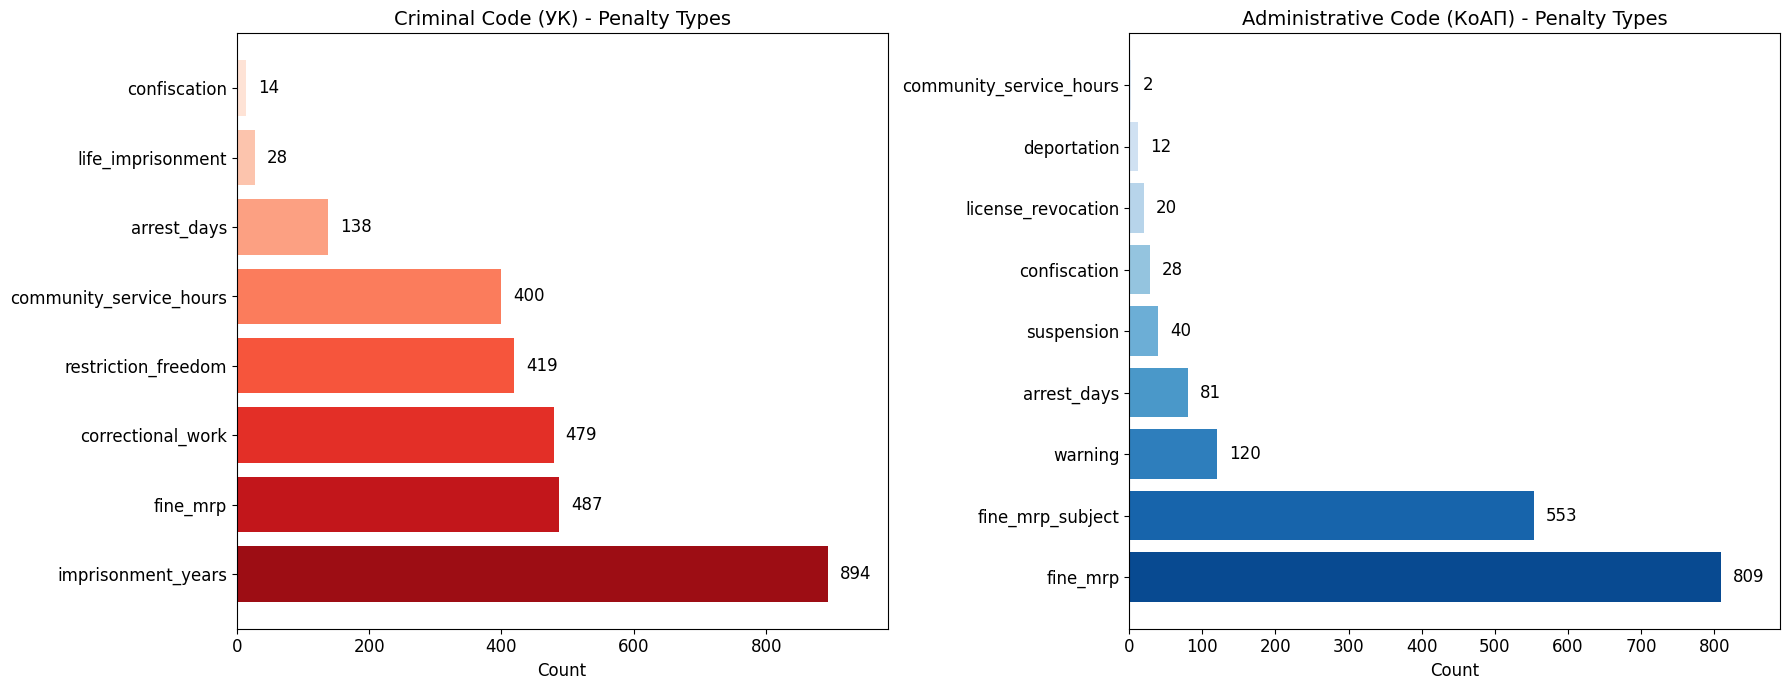

In [15]:
# Visualize penalty type distribution
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Criminal Code penalties
ax1 = axes[0]
criminal_counts = penalties_df[penalties_df["code_type"] == "Criminal"]["penalty_type"].value_counts()
if len(criminal_counts) > 0:
    colors1 = sns.color_palette("Reds_r", len(criminal_counts))
    bars1 = ax1.barh(range(len(criminal_counts)), criminal_counts.values, color=colors1)
    ax1.set_yticks(range(len(criminal_counts)))
    ax1.set_yticklabels(criminal_counts.index, fontsize=12)
    ax1.set_xlabel("Count", fontsize=12)
    ax1.set_title("Criminal Code (УК) - Penalty Types", fontsize=14)
    ax1.tick_params(axis='x', labelsize=12)
    # Extend x-axis to fit labels
    max_val1 = criminal_counts.values.max()
    ax1.set_xlim(0, max_val1 * 1.1)
    for bar, val in zip(bars1, criminal_counts.values):
        ax1.text(bar.get_width() + max_val1 * 0.02, bar.get_y() + bar.get_height()/2, 
                 str(val), va='center', fontsize=12)

# Administrative Code penalties
ax2 = axes[1]
admin_counts = penalties_df[penalties_df["code_type"] == "Administrative"]["penalty_type"].value_counts()
if len(admin_counts) > 0:
    colors2 = sns.color_palette("Blues_r", len(admin_counts))
    bars2 = ax2.barh(range(len(admin_counts)), admin_counts.values, color=colors2)
    ax2.set_yticks(range(len(admin_counts)))
    ax2.set_yticklabels(admin_counts.index, fontsize=12)
    ax2.set_xlabel("Count", fontsize=12)
    ax2.set_title("Administrative Code (КоАП) - Penalty Types", fontsize=14)
    ax2.tick_params(axis='x', labelsize=12)
    # Extend x-axis to fit labels
    max_val2 = admin_counts.values.max()
    ax2.set_xlim(0, max_val2 * 1.1)
    for bar, val in zip(bars2, admin_counts.values):
        ax2.text(bar.get_width() + max_val2 * 0.02, bar.get_y() + bar.get_height()/2, 
                 str(val), va='center', fontsize=12)

plt.tight_layout()
plt.savefig("../output/03/penalty_type_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

## 5. Fine Amount Analysis

In [16]:
# Analyze fine amounts (in MRP - Месячный Расчетный Показатель)
fines_df = penalties_df[
    penalties_df["penalty_type"].isin(["fine_mrp", "fine_mrp_alt"])
].copy()

# Filter out invalid values
fines_df = fines_df[fines_df["max_value"].notna()]

print(f"Fine penalties with values: {len(fines_df):,}")
print(f"\nBy code type:")
print(fines_df["code_type"].value_counts())

# Statistics
if len(fines_df) > 0:
    print(f"\nFine amount statistics (max_value in MRP):")
    print(fines_df.groupby("code_type")["max_value"].describe())
else:
    print("\nNo fine data with values available")

Fine penalties with values: 1,296

By code type:
code_type
Administrative    809
Criminal          487
Name: count, dtype: int64

Fine amount statistics (max_value in MRP):
                count         mean          std   min    25%     50%     75%  \
code_type                                                                      
Administrative  809.0    83.563659   176.783581   1.0   15.0    30.0   100.0   
Criminal        487.0  2259.630390  1848.051545  80.0  200.0  2000.0  3000.0   

                   max  
code_type               
Administrative  2000.0  
Criminal        8000.0  


In [140]:
fines_df.head(3)

,code_type,article_id,article_title,section,chapter,part,num_alternatives,penalty_type,min_value,max_value,has_value
25,Criminal,z452,Статья 107. Умышленное причинение средней тяже...,РАЗДЕЛ 7. ПРИНУДИТЕЛЬНЫЕ МЕРЫ МЕДИЦИНСКОГО ХАР...,None,1,4,fine_mrp,NaN,1000.0,True
30,Criminal,z2902,Статья 108-1. Умышленное причинение легкого вр...,РАЗДЕЛ 7. ПРИНУДИТЕЛЬНЫЕ МЕРЫ МЕДИЦИНСКОГО ХАР...,None,1,4,fine_mrp,NaN,200.0,True
34,Criminal,z2902,Статья 108-1. Умышленное причинение легкого вр...,РАЗДЕЛ 7. ПРИНУДИТЕЛЬНЫЕ МЕРЫ МЕДИЦИНСКОГО ХАР...,None,8,5,fine_mrp,NaN,1000.0,True


In [19]:
# Check for outliers in fine data
print("Fine value statistics:")
print(fines_df.groupby("code_type")["max_value"].describe())

# Top fines by code type
print("\n" + "="*70)
print("TOP 10 HIGHEST FINES - CRIMINAL CODE (УК)")
print("="*70)
crim_top = fines_df[fines_df["code_type"] == "Criminal"].nlargest(10, "max_value")
for _, row in crim_top.iterrows():
    print(f"  {row['max_value']:.0f} MRP - {row['article_title'][:60]}")

print("\n" + "="*70)
print("TOP 10 HIGHEST FINES - ADMINISTRATIVE CODE (КоАП)")
print("="*70)
admin_top = fines_df[fines_df["code_type"] == "Administrative"].nlargest(10, "max_value")
for _, row in admin_top.iterrows():
    print(f"  {row['max_value']:.0f} MRP - {row['article_title'][:60]}")

# Check if there are unrealistic values (likely parsing errors)
print(f"\nFines > 10000 MRP (potential outliers):")
outliers = fines_df[fines_df["max_value"] > 10000]
print(f"  Count: {len(outliers)}")
if len(outliers) > 0:
    print(outliers[["code_type", "article_title", "max_value"]].head(10))

Fine value statistics:
                count         mean          std   min    25%     50%     75%  \
code_type                                                                      
Administrative  809.0    83.563659   176.783581   1.0   15.0    30.0   100.0   
Criminal        487.0  2259.630390  1848.051545  80.0  200.0  2000.0  3000.0   

                   max  
code_type               
Administrative  2000.0  
Criminal        8000.0  

TOP 10 HIGHEST FINES - CRIMINAL CODE (УК)
  8000 MRP - Статья 143. Незаконный вывоз несовершеннолетнего лица за пре
  7000 MRP - Статья 174. Разжигание социальной, национальной, родовой, ра
  7000 MRP - Статья 179. Пропаганда или публичные призывы к захвату или у
  7000 MRP - Статья 202. Умышленное уничтожение или повреждение чужого им
  7000 MRP - Статья 218. Легализация (отмывание) денег и (или) иного имущ
  7000 MRP - Статья 218-1. Сокрытие незаконно приобретенных активов от об
  7000 MRP - Статья 293. Хулиганство
  7000 MRP - Статья 339. Незакон

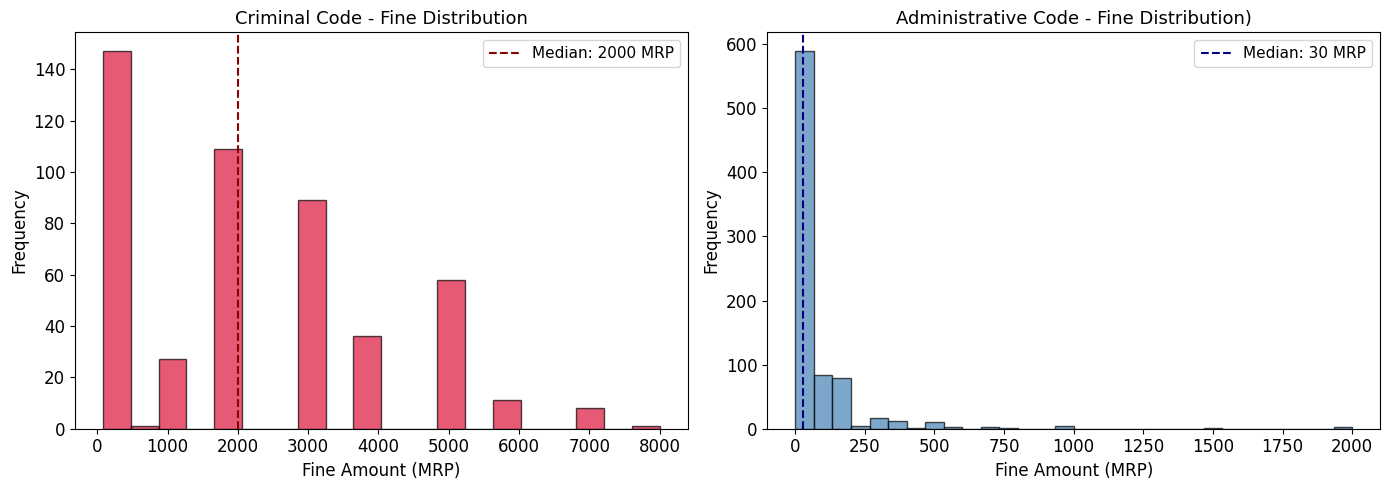


Fine Distribution Summary:
  Criminal Code:       median=2000 MRP, max=8000 MRP
  Administrative Code: median=30 MRP, max=2000 MRP


In [18]:
# Visualize fine distributions (with outlier handling)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Filter to reasonable MRP range (up to 10000 MRP is typical max)
MAX_REASONABLE_MRP = 10000

# Criminal fines
ax1 = axes[0]
criminal_fines = fines_df[fines_df["code_type"] == "Criminal"]["max_value"].dropna()
criminal_fines_filtered = criminal_fines[criminal_fines <= MAX_REASONABLE_MRP]
if len(criminal_fines_filtered) > 0:
    ax1.hist(criminal_fines_filtered, bins=20, color='crimson', alpha=0.7, edgecolor='black')
    ax1.axvline(criminal_fines_filtered.median(), color='darkred', linestyle='--', 
                label=f'Median: {criminal_fines_filtered.median():.0f} MRP')
    ax1.set_xlabel("Fine Amount (MRP)", fontsize=12)
    ax1.set_ylabel("Frequency", fontsize=12)
    ax1.set_title(f"Criminal Code - Fine Distribution", fontsize=13)
    ax1.tick_params(axis='both', labelsize=12)
    ax1.legend(fontsize=11)
else:
    ax1.text(0.5, 0.5, "No Criminal Code fines", ha='center', va='center', transform=ax1.transAxes)
    ax1.set_title("Criminal Code - Fine Distribution", fontsize=13)

# Administrative fines
ax2 = axes[1]
admin_fines = fines_df[fines_df["code_type"] == "Administrative"]["max_value"].dropna()
admin_fines_filtered = admin_fines[admin_fines <= MAX_REASONABLE_MRP]
outlier_count = len(admin_fines) - len(admin_fines_filtered)

if len(admin_fines_filtered) > 0:
    ax2.hist(admin_fines_filtered, bins=30, color='steelblue', alpha=0.7, edgecolor='black')
    ax2.axvline(admin_fines_filtered.median(), color='navy', linestyle='--', 
                label=f'Median: {admin_fines_filtered.median():.0f} MRP')
    ax2.set_xlabel("Fine Amount (MRP)", fontsize=12)
    ax2.set_ylabel("Frequency", fontsize=12)
    title = f"Administrative Code - Fine Distribution"
    if outlier_count > 0:
        title += f", {outlier_count} outliers excluded"
    title += ")"
    ax2.set_title(title, fontsize=13)
    ax2.tick_params(axis='both', labelsize=12)
    ax2.legend(fontsize=11)

plt.tight_layout()
plt.savefig("../output/03/fine_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

# Summary
print(f"\nFine Distribution Summary:")
print(f"  Criminal Code:       median={criminal_fines_filtered.median():.0f} MRP, max={criminal_fines_filtered.max():.0f} MRP")
print(f"  Administrative Code: median={admin_fines_filtered.median():.0f} MRP, max={admin_fines_filtered.max():.0f} MRP")
if outlier_count > 0:
    print(f"  Note: {outlier_count} outlier(s) excluded (values > {MAX_REASONABLE_MRP} MRP - likely parsing errors)")

## 7. Administrative Arrest Analysis

In [143]:
# Analyze arrest terms
arrest_df = penalties_df[
    penalties_df["penalty_type"].isin(["arrest_days", "admin_arrest"])
].copy()

arrest_df = arrest_df[arrest_df["max_value"].notna()]

print(f"Arrest penalties with values: {len(arrest_df):,}")
print(f"\nBy code type:")
print(arrest_df["code_type"].value_counts())

if len(arrest_df) > 0:
    print(f"\nArrest term statistics (days):")
    print(arrest_df.groupby("code_type")["max_value"].describe())

Arrest penalties with values: 219

By code type:
code_type
Criminal          138
Administrative     81
Name: count, dtype: int64

Arrest term statistics (days):
                count       mean        std   min   25%   50%   75%   max
code_type                                                                
Administrative   81.0  16.209877  10.562571   3.0  10.0  15.0  20.0  50.0
Criminal        138.0  41.956522  10.277798  20.0  40.0  40.0  50.0  80.0


## 8. Penalties by Chapter/Section

In [144]:
# Analyze most common penalty types by chapter (Criminal Code)
criminal_by_chapter = penalties_df[
    penalties_df["code_type"] == "Criminal"
].groupby(["chapter", "penalty_type"]).size().unstack(fill_value=0)

# Get top chapters by total penalties
top_chapters = criminal_by_chapter.sum(axis=1).nlargest(10)

print("Top 10 Criminal Code Chapters by Penalty Count:")
for chapter, count in top_chapters.items():
    print(f"  {chapter}: {count}")

Top 10 Criminal Code Chapters by Penalty Count:
  Глава 8. УГОЛОВНЫЕ ПРАВОНАРУШЕНИЯ В СФЕРЕ ЭКОНОМИЧЕСКОЙ ДЕЯТЕЛЬНОСТИ: 346
  Глава 16. УГОЛОВНЫЕ ПРАВОНАРУШЕНИЯ ПРОТИВ ПОРЯДКА УПРАВЛЕНИЯ: 288
  Глава 10. УГОЛОВНЫЕ ПРАВОНАРУШЕНИЯ ПРОТИВ ОБЩЕСТВЕННОЙ БЕЗОПАСНОСТИ И ОБЩЕСТВЕННОГО ПОРЯДКА: 247
  Глава 17. УГОЛОВНЫЕ ПРАВОНАРУШЕНИЯ ПРОТИВ ПРАВОСУДИЯ И ПОРЯДКА ИСПОЛНЕНИЯ НАКАЗАНИЙ, КОНСТИТУЦИОННОГО ПРОИЗВОДСТВА: 238
  Глава 13. ЭКОЛОГИЧЕСКИЕ УГОЛОВНЫЕ ПРАВОНАРУШЕНИЯ: 201
  Глава 18. ВОИНСКИЕ УГОЛОВНЫЕ ПРАВОНАРУШЕНИЯ: 192
  Глава 6. УГОЛОВНЫЕ ПРАВОНАРУШЕНИЯ ПРОТИВ СОБСТВЕННОСТИ: 185
  Глава 14. ТРАНСПОРТНЫЕ УГОЛОВНЫЕ ПРАВОНАРУШЕНИЯ: 176
  Глава 11. УГОЛОВНЫЕ ПРАВОНАРУШЕНИЯ ПРОТИВ ЗДОРОВЬЯ НАСЕЛЕНИЯ И НРАВСТВЕННОСТИ: 172
  Глава 3. УГОЛОВНЫЕ ПРАВОНАРУШЕНИЯ ПРОТИВ КОНСТИТУЦИОННЫХ И ИНЫХ ПРАВ И СВОБОД ЧЕЛОВЕКА И ГРАЖДАНИНА: 130


In [145]:
# Analyze most common penalty types by chapter (Administrative Code)
admin_by_chapter = penalties_df[
    penalties_df["code_type"] == "Administrative"
].groupby(["chapter", "penalty_type"]).size().unstack(fill_value=0)

# Get top chapters by total penalties
top_admin_chapters = admin_by_chapter.sum(axis=1).nlargest(10)

print("Top 10 Administrative Code Chapters by Penalty Count:")
for chapter, count in top_admin_chapters.items():
    print(f"  {chapter}: {count}")

Top 10 Administrative Code Chapters by Penalty Count:
  Глава 15. АДМИНИСТРАТИВНЫЕ ПРАВОНАРУШЕНИЯ В ОБЛАСТИ ТОРГОВЛИ И ФИНАНСОВ: 244
  Глава 30. АДМИНИСТРАТИВНЫЕ ПРАВОНАРУШЕНИЯ НА ТРАНСПОРТЕ, В ДОРОЖНОМ ХОЗЯЙСТВЕ: 227
  Глава 27. АДМИНИСТРАТИВНЫЕ ПРАВОНАРУШЕНИЯ, ПОСЯГАЮЩИЕ НА УСТАНОВЛЕННЫЙ ПОРЯДОК УПРАВЛЕНИЯ: 170
  Глава 21. АДМИНИСТРАТИВНЫЕ ПРАВОНАРУШЕНИЯ В ОБЛАСТИ ОХРАНЫ ОКРУЖАЮЩЕЙ СРЕДЫ, ИСПОЛЬЗОВАНИЯ ПРИРОДНЫХ РЕСУРСОВ: 148
  Глава 14. Административные правонарушения в области предпринимательской деятельности, а также реабилитации, восстановления платежеспособности и банкротства: 131
  Глава 9. АДМИНИСТРАТИВНАЯ ОТВЕТСТВЕННОСТЬ НЕСОВЕРШЕННОЛЕТНИХ: 77
  Глава 25. АДМИНИСТРАТИВНЫЕ ПРАВОНАРУШЕНИЯ, ПОСЯГАЮЩИЕ НА ОБЩЕСТВЕННЫЙ ПОРЯДОК И НРАВСТВЕННОСТЬ: 76
  Глава 16. АДМИНИСТРАТИВНЫЕ ПРАВОНАРУШЕНИЯ В ОБЛАСТИ НАЛОГООБЛОЖЕНИЯ: 75
  Глава 24. АДМИНИСТРАТИВНЫЕ ПРАВОНАРУШЕНИЯ, ПОСЯГАЮЩИЕ НА ОБЩЕСТВЕННУЮ БЕЗОПАСНОСТЬ И ЗДОРОВЬЕ НАСЕЛЕНИЯ: 54
  Глава 33. АДМИНИСТРАТИВНЫЕ ПРАВОНАРУШЕНИЯ, ПОСЯГАЮЩ

## 9. Severity Comparison

In [146]:
# Create severity score (normalized)
# For fines: use max_value as proxy
# For imprisonment: use max_value * 365 (convert years to days equivalent)

def calculate_severity(row):
    """Calculate a relative severity score."""
    if pd.isna(row["max_value"]):
        return 0
    
    penalty_type = row["penalty_type"]
    value = row["max_value"]
    
    if penalty_type == "imprisonment":
        return value * 100  # Highest weight for imprisonment
    elif penalty_type == "life_imprisonment":
        return 5000  # Very high
    elif penalty_type == "death_penalty":
        return 10000  # Highest
    elif penalty_type in ["fine_mrp", "fine_mrp_simple", "fine_salary"]:
        return value * 0.1  # Lower weight for fines
    elif penalty_type == "arrest":
        return value * 2  # Medium weight for arrest
    elif penalty_type in ["restriction_freedom", "correctional_work"]:
        return value * 10  # Medium-high
    else:
        return 1  # Default low severity

penalties_df["severity_score"] = penalties_df.apply(calculate_severity, axis=1)

# Compare severity distributions
print("Severity Score Statistics by Code Type:")
penalties_df.groupby("code_type")["severity_score"].describe()

Severity Score Statistics by Code Type:


,count,mean,std,min,25%,50%,75%,max
code_type,,,,,,,,
Administrative,1665.0,4.442222,12.897320,0.0,1.0,1.0,3.0,200.0
Criminal,2859.0,38.678559,114.069077,0.0,0.0,0.0,1.0,800.0


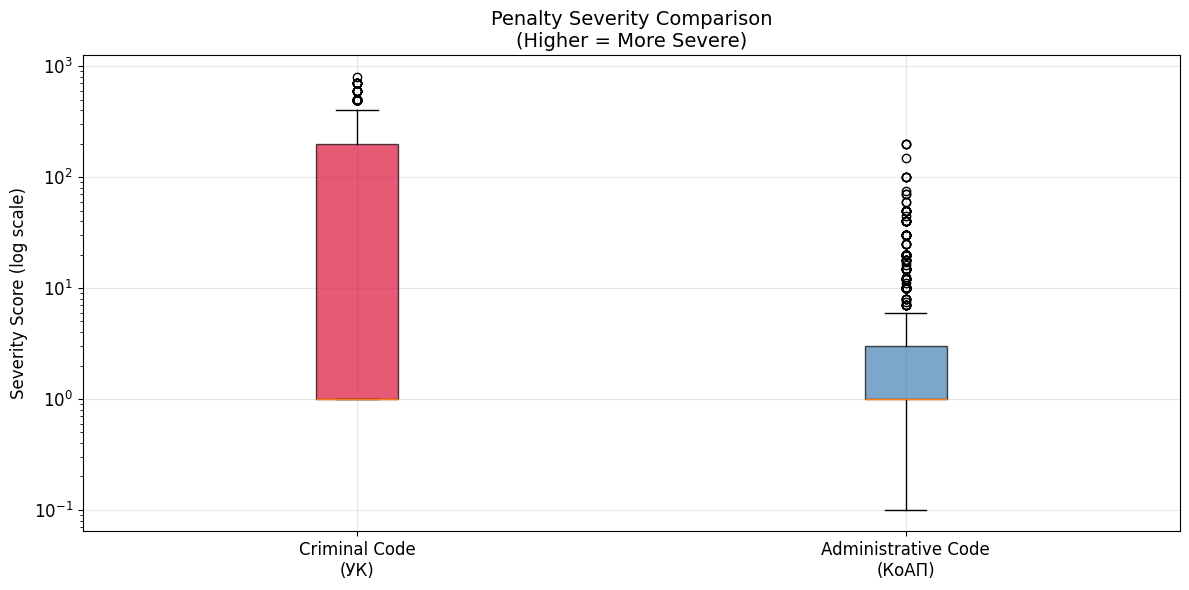

In [147]:
# Visualize severity comparison
fig, ax = plt.subplots(figsize=(12, 6))

criminal_severity = penalties_df[
    (penalties_df["code_type"] == "Criminal") & 
    (penalties_df["severity_score"] > 0)
]["severity_score"]

admin_severity = penalties_df[
    (penalties_df["code_type"] == "Administrative") & 
    (penalties_df["severity_score"] > 0)
]["severity_score"]

data = [criminal_severity, admin_severity]
labels = ["Criminal Code\n(УК)", "Administrative Code\n(КоАП)"]
colors = ["crimson", "steelblue"]

bp = ax.boxplot(data, labels=labels, patch_artist=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_ylabel("Severity Score (log scale)", fontsize=12)
ax.set_yscale("log")
ax.set_title("Penalty Severity Comparison\n(Higher = More Severe)", fontsize=14)
ax.tick_params(axis='both', labelsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../output/03/severity_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

## 10. Summary and Export

In [149]:
print("="*70)
print("KEY FINDINGS - Penalty and Sanction Patterns Analysis")
print("="*70)

# Calculate actual values from the data
total_penalties = len(penalties_df)
criminal_count = len(penalties_df[penalties_df["code_type"] == "Criminal"])
admin_count = len(penalties_df[penalties_df["code_type"] == "Administrative"])
total_groups = len(penalties_grouped_df)
groups_with_alternatives = (penalties_grouped_df['num_alternatives'] > 1).sum()

print("\n" + "="*70)
print("1. PENALTY EXTRACTION OVERVIEW")
print("="*70)
print(f"""
   DATA VERSIONS:
   • Criminal Code (УК): version {criminal_version['version_number']} ({criminal_version['version_date']})
   • Administrative Code (КоАП): version {admin_version['version_number']} ({admin_version['version_date']})
   
   TOTAL PENALTY RECORDS: {total_penalties:,} extracted
   
   BY CODE:
   • Criminal Code (УК):        {criminal_count:,} penalties ({criminal_count/total_penalties*100:.0f}%)
   • Administrative Code (КоАП): {admin_count:,} penalties ({admin_count/total_penalties*100:.0f}%)
   
   PENALTY GROUPS (article-parts with sentencing):
   • Total groups: {total_groups:,}
   • Groups with alternatives: {groups_with_alternatives:,} ({groups_with_alternatives/total_groups*100:.0f}%) - "either/or" sentencing
""")

print("="*70)
print("2. PENALTY TYPE DISTRIBUTION")
print("="*70)

# Get actual counts
crim_types = penalties_df[penalties_df["code_type"] == "Criminal"]["penalty_type"].value_counts()
admin_types = penalties_df[penalties_df["code_type"] == "Administrative"]["penalty_type"].value_counts()

print(f"""
   CRIMINAL CODE (УК) - Top Penalty Types:
   ─────────────────────────────────────────────────────────────────────""")
for ptype, count in crim_types.head(8).items():
    pct = count / criminal_count * 100
    print(f"   {ptype:28} {count:>5}   ({pct:>4.1f}%)")

print(f"""
   ADMINISTRATIVE CODE (КоАП) - Top Penalty Types:
   ─────────────────────────────────────────────────────────────────────""")
for ptype, count in admin_types.head(8).items():
    pct = count / admin_count * 100
    print(f"   {ptype:28} {count:>5}   ({pct:>4.1f}%)")

print("="*70)
print("3. SENTENCING ALTERNATIVES (JUDICIAL DISCRETION)")
print("="*70)

# Calculate alternatives stats
crim_groups = penalties_grouped_df[penalties_grouped_df['code_type'] == 'Criminal']
admin_groups = penalties_grouped_df[penalties_grouped_df['code_type'] == 'Administrative']

crim_single = (crim_groups['num_alternatives'] == 1).sum()
crim_multi = (crim_groups['num_alternatives'] > 1).sum()
crim_avg_alt = crim_groups['num_alternatives'].mean()
crim_max_alt = crim_groups['num_alternatives'].max()

admin_single = (admin_groups['num_alternatives'] == 1).sum()
admin_multi = (admin_groups['num_alternatives'] > 1).sum()
admin_avg_alt = admin_groups['num_alternatives'].mean()
admin_max_alt = admin_groups['num_alternatives'].max()

print(f"""
   CRIMINAL CODE:
   • Total article-parts with penalties: {len(crim_groups):,}
   • Single penalty only:     {crim_single:,} ({crim_single/len(crim_groups)*100:.1f}%) - No judicial choice
   • Multiple alternatives:   {crim_multi:,} ({crim_multi/len(crim_groups)*100:.1f}%) - Judge chooses
   • Average alternatives:    {crim_avg_alt:.2f} per article-part
   • Maximum alternatives:    {crim_max_alt} (e.g., fine OR work OR arrest OR...)
   
   ADMINISTRATIVE CODE:
   • Total article-parts with penalties: {len(admin_groups):,}
   • Single penalty only:     {admin_single:,} ({admin_single/len(admin_groups)*100:.1f}%) - Fixed sanction
   • Multiple alternatives:   {admin_multi:,} ({admin_multi/len(admin_groups)*100:.1f}%) - Limited discretion
   • Average alternatives:    {admin_avg_alt:.2f} per article-part
   • Maximum alternatives:    {admin_max_alt}
   
   KEY INSIGHT: Criminal Code provides more judicial discretion
   in sentencing compared to Administrative Code ({crim_multi/len(crim_groups)*100:.0f}% vs {admin_multi/len(admin_groups)*100:.0f}% choice).
""")

print("="*70)
print("4. FINE AMOUNTS (MRP - Monthly Calculation Index)")
print("="*70)

# Get fine statistics
crim_fines = fines_df[fines_df["code_type"] == "Criminal"]["max_value"]
admin_fines = fines_df[fines_df["code_type"] == "Administrative"]["max_value"]

print(f"""
   CRIMINAL CODE FINES:
   ─────────────────────────────────────────────────────────────────────
   Count:     {len(crim_fines):,} fine penalties
   Minimum:   {crim_fines.min():.0f} MRP
   Median:    {crim_fines.median():,.0f} MRP
   Mean:      {crim_fines.mean():,.0f} MRP
   Maximum:   {crim_fines.max():,.0f} MRP
   
   ADMINISTRATIVE CODE FINES:
   ─────────────────────────────────────────────────────────────────────
   Count:     {len(admin_fines):,} fine penalties
   Minimum:   {admin_fines.min():.0f} MRP
   Median:    {admin_fines.median():.0f} MRP
   Mean:      {admin_fines.mean():.0f} MRP
   Maximum:   {admin_fines.max():,.0f} MRP
   
   RATIO: Criminal fines are ~{crim_fines.median()/admin_fines.median():.0f}x higher (median {crim_fines.median():.0f} vs {admin_fines.median():.0f} MRP)
""")

# Get highest fines
top_crim_fines = fines_df[fines_df["code_type"] == "Criminal"].nlargest(5, "max_value")
print(f"   HIGHEST CRIMINAL FINES ({top_crim_fines['max_value'].max():.0f} MRP):")
for _, row in top_crim_fines[top_crim_fines['max_value'] == top_crim_fines['max_value'].max()].iterrows():
    title_short = row['article_title'][:50] if len(row['article_title']) > 50 else row['article_title']
    print(f"   • {title_short}")

print("="*70)
print("5. IMPRISONMENT TERMS (Criminal Code Only)")
print("="*70)

imprison_count = crim_types.get('imprisonment_years', 0)
life_count = crim_types.get('life_imprisonment', 0)

print(f"""
   IMPRISONMENT STATISTICS:
   ─────────────────────────────────────────────────────────────────────
   Count:     {imprison_count:,} imprisonment penalties
   Most common range: 1-10 years
   Maximum fixed term: 20-25 years
   
   LIFE IMPRISONMENT:
   • {life_count} articles mention life imprisonment
   • Reserved for most serious crimes (murder, terrorism, etc.)
   
   NOTE: Administrative Code has NO imprisonment - only short arrests
""")

print("="*70)
print("6. ARREST DURATION COMPARISON")
print("="*70)

crim_arrests = arrest_df[arrest_df["code_type"] == "Criminal"]["max_value"]
admin_arrests = arrest_df[arrest_df["code_type"] == "Administrative"]["max_value"]

print(f"""
   CRIMINAL CODE ARRESTS:
   ─────────────────────────────────────────────────────────────────────
   Count:    {len(crim_arrests):,} arrest penalties
   Mean:     {crim_arrests.mean():.0f} days
   Median:   {crim_arrests.median():.0f} days
   Maximum:  {crim_arrests.max():.0f} days
   
   ADMINISTRATIVE CODE ARRESTS:
   ─────────────────────────────────────────────────────────────────────
   Count:    {len(admin_arrests):,} arrest penalties
   Mean:     {admin_arrests.mean():.0f} days
   Median:   {admin_arrests.median():.0f} days
   Maximum:  {admin_arrests.max():.0f} days
   
   Criminal arrests are {crim_arrests.mean()/admin_arrests.mean():.1f}x longer on average ({crim_arrests.mean():.0f} vs {admin_arrests.mean():.0f} days)
""")

print("="*70)
print("7. TOP CHAPTERS BY PENALTY COUNT")
print("="*70)
print(f"""
   CRIMINAL CODE - Most Penalized Areas:
   ─────────────────────────────────────────────────────────────────────""")
for i, (chapter, count) in enumerate(top_chapters.head(5).items(), 1):
    chapter_short = chapter[:60] if len(chapter) > 60 else chapter
    print(f"   {i}. {chapter_short}: {count}")

print(f"""
   ADMINISTRATIVE CODE - Most Penalized Areas:
   ─────────────────────────────────────────────────────────────────────""")
for i, (chapter, count) in enumerate(top_admin_chapters.head(5).items(), 1):
    chapter_short = chapter[:60] if len(chapter) > 60 else chapter
    print(f"   {i}. {chapter_short}: {count}")

print("="*70)
print("8. SEVERITY COMPARISON")
print("="*70)

crim_severity = penalties_df[penalties_df["code_type"] == "Criminal"]["severity_score"]
admin_severity = penalties_df[penalties_df["code_type"] == "Administrative"]["severity_score"]

print(f"""
   SEVERITY SCORES (normalized):
   ─────────────────────────────────────────────────────────────────────
                  CRIMINAL        ADMINISTRATIVE
   Mean:          {crim_severity.mean():.1f}            {admin_severity.mean():.1f}
   Median:        {crim_severity.median():.1f}             {admin_severity.median():.1f}
   Maximum:       {crim_severity.max():.0f}             {admin_severity.max():.0f}
   
   SEVERITY HIERARCHY:
   1. Life imprisonment (Criminal only)
   2. Long-term imprisonment (Criminal only)
   3. Large fines (Criminal: {crim_fines.median():.0f}+ MRP)
   4. Restriction of freedom (Criminal only)
   5. Correctional work (Criminal only)
   6. Arrest (Both codes, Criminal longer)
   7. Small fines (Admin: {admin_fines.median():.0f} MRP median)
   8. Warning (Admin only - lowest)
""")

print("="*70)
print("9. DEATH PENALTY STATUS")
print("="*70)
print(f"""
   • Death penalty mentions in code: 0
   • Kazakhstan has maintained a MORATORIUM since 2003
   • Death penalty is NOT applied in practice
   • 2021: Signed Second Optional Protocol to ICCPR
   • Status: De facto abolished, moving toward full abolition
""")

print("="*70)
print("10. KEY INSIGHTS FOR LEGAL AI/NLP")
print("="*70)
print(f"""
   STRUCTURAL PATTERNS:
   • Criminal penalties favor judicial discretion ({crim_multi/len(crim_groups)*100:.0f}% alternatives)
   • Administrative penalties are mostly fixed ({admin_single/len(admin_groups)*100:.0f}% no choice)
   • Imprisonment is ONLY in Criminal Code
   • Warnings are ONLY in Administrative Code
   
   SEVERITY INDICATORS:
   • Imprisonment term → High severity
   • Fine amount (MRP) → Graduated severity
   • Arrest days → Medium severity
   • Warning → Lowest severity
   
   PARSING CHALLENGES:
   • Russian compound numbers (семисот пятидесяти = 750)
   • Multiple penalty alternatives in single sentence
   • Subject-differentiated fines (физ/должн/юр лица)
   • Range formats: "от X до Y" vs "до X" vs exact values
   
   CORPUS SUMMARY:
   • Total penalties extracted: {total_penalties:,}
   • Penalty groups: {total_groups:,}
   • Fine penalties with values: {len(fines_df):,}
   • Arrest penalties with values: {len(arrest_df):,}
""")

print("="*70)

KEY FINDINGS - Penalty and Sanction Patterns Analysis

1. PENALTY EXTRACTION OVERVIEW

   DATA VERSIONS:
   • Criminal Code (УК): version 109 (16.09.2025)
   • Administrative Code (КоАП): version 205 (17.12.2025)

   TOTAL PENALTY RECORDS: 4,524 extracted

   BY CODE:
   • Criminal Code (УК):        2,859 penalties (63%)
   • Administrative Code (КоАП): 1,665 penalties (37%)

   PENALTY GROUPS (article-parts with sentencing):
   • Total groups: 2,624
   • Groups with alternatives: 693 (26%) - "either/or" sentencing

2. PENALTY TYPE DISTRIBUTION

   CRIMINAL CODE (УК) - Top Penalty Types:
   ─────────────────────────────────────────────────────────────────────
   imprisonment_years             894   (31.3%)
   fine_mrp                       487   (17.0%)
   correctional_work              479   (16.8%)
   restriction_freedom            419   (14.7%)
   community_service_hours        400   (14.0%)
   arrest_days                    138   ( 4.8%)
   life_imprisonment               28   ( 1.

In [150]:
# Export results
penalties_df.to_csv("../output/03/all_penalties.csv", index=False)

# Summary by type
penalty_summary = penalties_df.groupby(["code_type", "penalty_type"]).agg({
    "article_id": "count",
    "min_value": "mean",
    "max_value": "mean",
    "severity_score": "mean"
}).round(2)
penalty_summary.columns = ["count", "avg_min_value", "avg_max_value", "avg_severity"]
penalty_summary.to_csv("../output/03/penalty_summary.csv")

print("Exported to output/03/:")
print("  - all_penalties.csv")
print("  - penalty_summary.csv")

Exported to output/03/:
  - all_penalties.csv
  - penalty_summary.csv
